In [2]:
import os
import shutil
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

from sklearn.metrics import classification_report, confusion_matrix

In [3]:
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2, EfficientNetB0

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [5]:
import os
import shutil
import random

original_dataset = "rice leaf diseases dataset"
base_dir = "dataset_split"

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

split_ratio = (0.7, 0.15, 0.15)

# Only keep folders (ignore .DS_Store and files)
classes = [d for d in os.listdir(original_dataset) 
           if os.path.isdir(os.path.join(original_dataset, d))]

for cls in classes:

    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

    class_path = os.path.join(original_dataset, cls)

    images = [f for f in os.listdir(class_path) 
              if os.path.isfile(os.path.join(class_path, f))]

    random.shuffle(images)

    train_split = int(split_ratio[0] * len(images))
    val_split = int((split_ratio[0] + split_ratio[1]) * len(images))

    train_images = images[:train_split]
    val_images = images[train_split:val_split]
    test_images = images[val_split:]

    for img in train_images:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(train_dir, cls, img))

    for img in val_images:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(val_dir, cls, img))

    for img in test_images:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(test_dir, cls, img))

print("Dataset successfully split into train / val / test")

Dataset successfully split into train / val / test


In [6]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    vertical_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

In [7]:
train_data = train_gen.flow_from_directory(
    "dataset_split/train",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

val_data = val_gen.flow_from_directory(
    "dataset_split/val",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

test_data = test_gen.flow_from_directory(
    "dataset_split/test",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

num_classes = train_data.num_classes

Found 5377 images belonging to 4 classes.
Found 1154 images belonging to 4 classes.
Found 1153 images belonging to 4 classes.


4 Base CNN Model (from your reference notebook)
This is your custom CNN baseline model.
Why we create baseline
In research you always compare with a simple model first.


In [8]:
model = Sequential([
Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
MaxPooling2D(2,2),

Conv2D(64,(3,3),activation='relu'),
MaxPooling2D(2,2),

Conv2D(128,(3,3),activation='relu'),
MaxPooling2D(2,2),

Flatten(),

Dense(128,activation='relu'),
Dropout(0.5),

Dense(num_classes,activation='softmax')
])

In [9]:
base_model = model.compile(
optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy']
)

In [10]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 54, 54, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 26, 26, 128)       0

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import Dense, Dropout, Flatten

def build_cnn_model(input_shape=(224,224,3), num_classes=4):

    model = Sequential([
        
        Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(256, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Flatten(),

        Dense(256, activation='relu'),
        Dropout(0.5),

        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [12]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

def build_transfer_model(base_model, num_classes=4):

    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=outputs)

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [13]:
models = {}

# Baseline CNN
models["CNN"] = build_cnn_model()

# Transfer Learning Models
models["VGG16"] = build_transfer_model(
    VGG16(weights="imagenet", include_top=False, input_shape=(224,224,3))
)

models["ResNet50"] = build_transfer_model(
    ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3))
)

models["MobileNetV2"] = build_transfer_model(
    MobileNetV2(weights="imagenet", include_top=False, input_shape=(224,224,3))
)

models["EfficientNetB0"] = build_transfer_model(
    EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224,224,3))
)

In [14]:
histories = {}
results = {}

for name, model in models.items():

    print("Training:", name)

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=10
    )

    histories[name] = history

Training: CNN
Epoch 1/10
169/169 [==============================] - 202s 1s/step - loss: 3.3207 - accuracy: 0.7288 - val_loss: 2.7831 - val_accuracy: 0.3544
Epoch 2/10
169/169 [==============================] - 200s 1s/step - loss: 1.0481 - accuracy: 0.7463 - val_loss: 0.9072 - val_accuracy: 0.6516
Epoch 3/10
169/169 [==============================] - 205s 1s/step - loss: 0.7458 - accuracy: 0.7497 - val_loss: 0.6460 - val_accuracy: 0.6846
Epoch 4/10
169/169 [==============================] - 207s 1s/step - loss: 0.9771 - accuracy: 0.7586 - val_loss: 40.0045 - val_accuracy: 0.6378
Epoch 5/10
169/169 [==============================] - 206s 1s/step - loss: 0.8240 - accuracy: 0.7502 - val_loss: 1.6265 - val_accuracy: 0.7929
Epoch 6/10
169/169 [==============================] - 205s 1s/step - loss: 0.5165 - accuracy: 0.7904 - val_loss: 0.5170 - val_accuracy: 0.7860
Epoch 7/10
169/169 [==============================] - 185s 1s/step - loss: 0.6877 - accuracy: 0.7508 - val_loss: 0.4239 - val_a

In [15]:
for name, model in models.items():

    train_loss, train_acc = model.evaluate(train_data)
    val_loss, val_acc = model.evaluate(val_data)
    test_loss, test_acc = model.evaluate(test_data)

    results[name] = [train_acc, val_acc, test_acc]

    print(name)
    print("Train Accuracy:", train_acc)
    print("Validation Accuracy:", val_acc)
    print("Test Accuracy:", test_acc)

37/37 [==============================] - 7s 197ms/step - loss: 0.2542 - accuracy: 0.8899
CNN
Train Accuracy: 0.8489864468574524
Validation Accuracy: 0.9064124822616577
Test Accuracy: 0.8898525834083557
37/37 [==============================] - 115s 3s/step - loss: 0.1153 - accuracy: 0.9566
VGG16
Train Accuracy: 0.9520178437232971
Validation Accuracy: 0.9601386189460754
Test Accuracy: 0.9566348791122437
37/37 [==============================] - 34s 920ms/step - loss: 0.8177 - accuracy: 0.6800
ResNet50
Train Accuracy: 0.6916496157646179
Validation Accuracy: 0.6793760657310486
Test Accuracy: 0.6799653172492981
37/37 [==============================] - 6s 159ms/step - loss: 0.0200 - accuracy: 0.9922
MobileNetV2
Train Accuracy: 0.9936767816543579
Validation Accuracy: 0.9930675625801086
Test Accuracy: 0.9921942949295044
37/37 [==============================] - 10s 278ms/step - loss: 1.3375 - accuracy: 0.3903
EfficientNetB0
Train Accuracy: 0.3905523419380188
Validation Accuracy: 0.38994801044464

In [16]:
class_names = list(train_data.class_indices.keys())
print(class_names)

['Bacterialblight', 'Brownspot', 'Leafsmut', 'NonRice']


37/37 [==============================] - 121s 3s/step


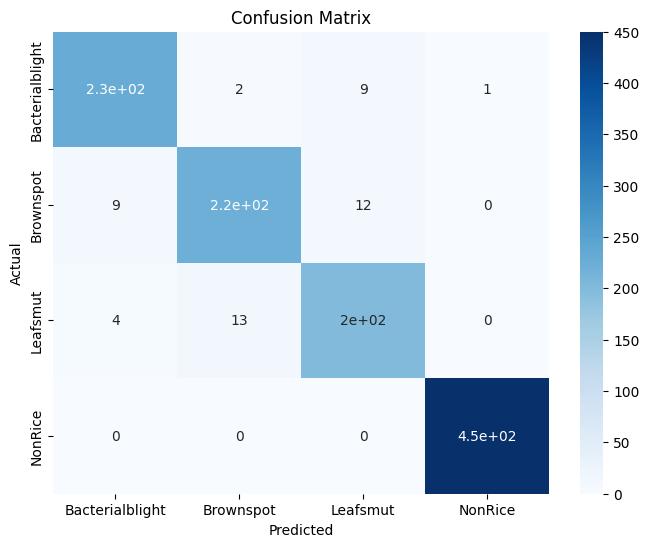

In [17]:
best_model = models["VGG16"]

pred = best_model.predict(test_data)
y_pred = np.argmax(pred, axis=1)

cm = confusion_matrix(test_data.classes, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [18]:
print(classification_report(
    test_data.classes,
    y_pred,
    target_names=class_names
))

                 precision    recall  f1-score   support

Bacterialblight       0.95      0.95      0.95       241
      Brownspot       0.94      0.91      0.92       243
       Leafsmut       0.91      0.92      0.91       219
        NonRice       1.00      1.00      1.00       450

       accuracy                           0.96      1153
      macro avg       0.95      0.95      0.95      1153
   weighted avg       0.96      0.96      0.96      1153



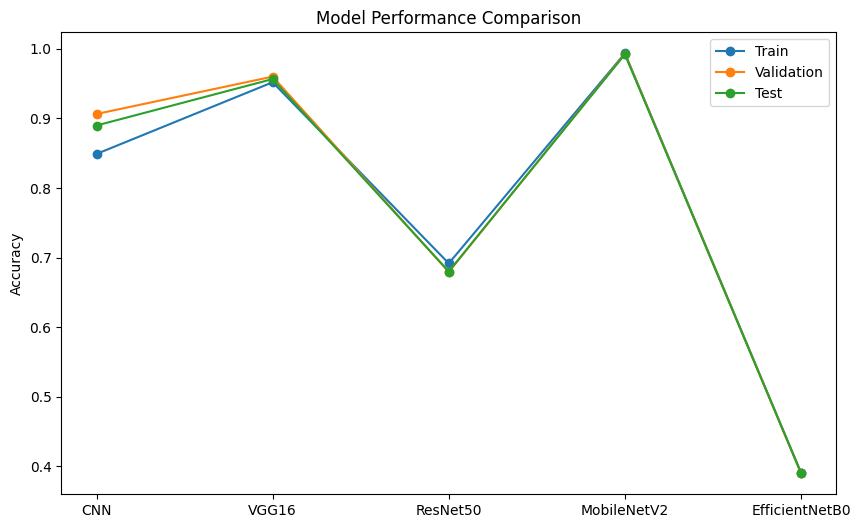

In [19]:
model_names = list(results.keys())

train_acc = [results[m][0] for m in model_names]
val_acc = [results[m][1] for m in model_names]
test_acc = [results[m][2] for m in model_names]

plt.figure(figsize=(10,6))

plt.plot(model_names, train_acc, marker="o", label="Train")
plt.plot(model_names, val_acc, marker="o", label="Validation")
plt.plot(model_names, test_acc, marker="o", label="Test")

plt.title("Model Performance Comparison")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [20]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model

In [36]:
best_model

In [21]:
best_model.save("rice_disease_model.keras")

In [23]:
best_model.save("rice_disease_model.h5")

/Users/yuvraj/New_Projects/Rice_plant_disease_Detection/tf_env/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [24]:
model = load_model("rice_disease_model.h5")

In [25]:
print(train_data.class_indices)

{'Bacterialblight': 0, 'Brownspot': 1, 'Leafsmut': 2, 'NonRice': 3}


In [26]:
medication = {
    "Bacterialblight": "Spray Streptocycline"
"""Recommended Treatment:
• Spray Streptomycin sulfate (0.015%)
• Apply Copper oxychloride fungicide
• Use resistant rice varieties
• Avoid excess nitrogen fertilizer""",
    "Brownspot": "Spray Mancozeb 75% WP"
"""Recommended Treatment:
• Spray Mancozeb (0.2%)
• Apply Carbendazim fungicide
• Maintain proper field drainage
• Apply balanced fertilizers""",
    "Leafblast": "Spray Tricyclazole"
"""Recommended Treatment:
• Spray Propiconazole
• Use certified disease-free seeds
• Remove infected leaves""",
    "Healthy": "No medication needed"
}

In [27]:
def preprocess_image(img_path):

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (224,224))
    img = img / 255.0

    img = np.expand_dims(img, axis=0)

    return img

In [28]:
def predict_rice_leaf(image_path):

    img = preprocess_image(image_path)

    predictions = model.predict(img)
    confidence = np.max(predictions)

    class_index = np.argmax(predictions)
    predicted_class = class_names[class_index]

    print("\nPredicted Class:", predicted_class)
    print("Confidence:", round(confidence*100,2), "%")

    # SHOW MEDICATION ONLY IF NOT NONRICE
    if predicted_class != "NonRice":
        print("\n💊 Suggested Medication:")
        print(medication.get(predicted_class, "Medication not available"))
    else:
        print("\n❌ This image is NOT a rice leaf")

    # show image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.imshow(image)
    plt.title(predicted_class)
    plt.axis("off")
    plt.show()

1/1 [==============================] - 0s 105ms/step

Predicted Class: NonRice
Confidence: 100.0 %

❌ This image is NOT a rice leaf


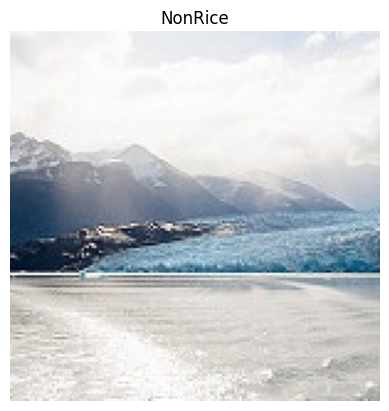

In [29]:
predict_rice_leaf('/Users/yuvraj/New_Projects/Rice_plant_disease_Detection/rice leaf diseases dataset/NonRice/20489.jpg')

1/1 [==============================] - 0s 74ms/step

Predicted Class: Brownspot
Confidence: 95.18 %

💊 Suggested Medication:
Spray Mancozeb 75% WPRecommended Treatment:
• Spray Mancozeb (0.2%)
• Apply Carbendazim fungicide
• Maintain proper field drainage
• Apply balanced fertilizers


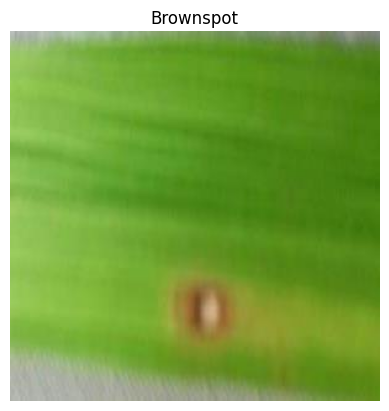

In [30]:
predict_rice_leaf("/Users/yuvraj/New_Projects/Rice_plant_disease_Detection/rice leaf diseases dataset/Leafsmut/BLAST4_160.jpg")

1/1 [==============================] - 0s 72ms/step

Predicted Class: Bacterialblight
Confidence: 99.57 %

💊 Suggested Medication:
Spray StreptocyclineRecommended Treatment:
• Spray Streptomycin sulfate (0.015%)
• Apply Copper oxychloride fungicide
• Use resistant rice varieties
• Avoid excess nitrogen fertilizer


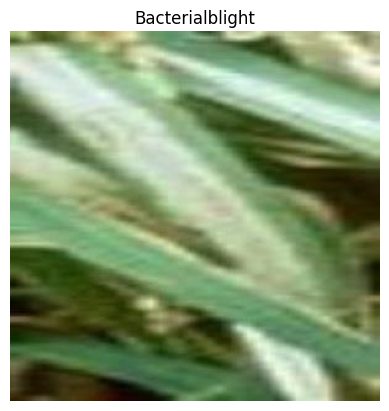

In [31]:
predict_rice_leaf('/Users/yuvraj/New_Projects/Rice_plant_disease_Detection/rice leaf diseases dataset/Bacterialblight/BACTERAILBLIGHT5_210.jpg')

37/37 [==============================] - 168s 5s/step


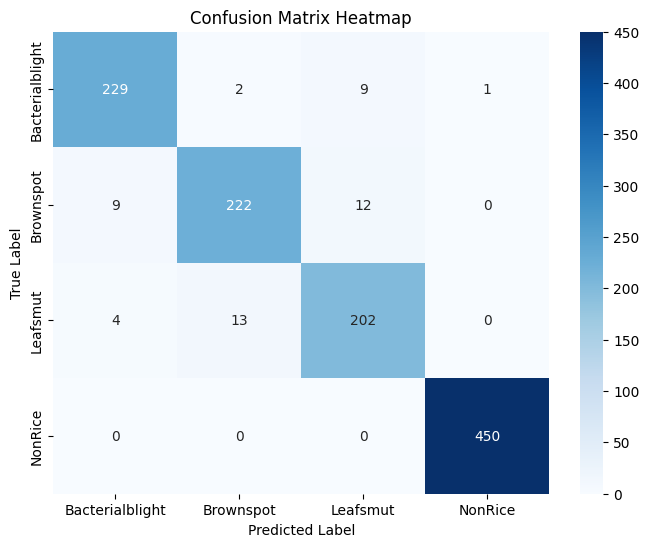

In [45]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Get true labels
true_labels = val_data.classes

# Predict
predictions = model.predict(val_data)
pred_labels = np.argmax(predictions, axis=1)

# Confusion matrix
#cm = confusion_matrix(true_labels, pred_labels)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=val_data.class_indices.keys(),
            yticklabels=val_data.class_indices.keys())

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [52]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Load trained model
model = load_model("rice_disease_model.h5")

# Image path
img_path = "/Users/yuvraj/New_Projects/Rice_plant_disease_Detection/dataset_split/test/Leafsmut/BLAST3_031.JPG"

# Load and preprocess image
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0


# IMPORTANT: check model.summary() to confirm last conv layer
last_conv_layer_name = "conv5_block3_out"


# Grad-CAM function
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    # Create model that outputs conv layer + predictions
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Record gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_index = tf.argmax(predictions[0])
        loss = predictions[:, class_index]

    # Compute gradients
    grads = tape.gradient(loss, conv_outputs)

    # Global average pooling
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    # Weight feature maps
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize heatmap safely
    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.reduce_max(heatmap)

    if max_val == 0:
        return heatmap.numpy()

    heatmap /= max_val

    return heatmap.numpy()


# Correct last convolution layer for VGG16
last_conv_layer_name = "block5_conv3"

# Generate heatmap
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

print("Heatmap generated successfully")

print("Heatmap generated successfully")

Heatmap generated successfully
Heatmap generated successfully


In [53]:
model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

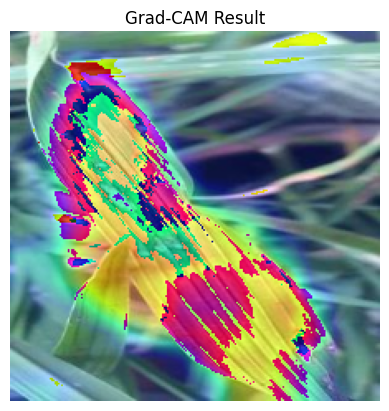

In [54]:
img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))

heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

plt.imshow(cv2.cvtColor(superimposed_img.astype("uint8"), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Grad-CAM Result")
plt.show()

one for the original leaf image and one for the Grad-CAM overlay.


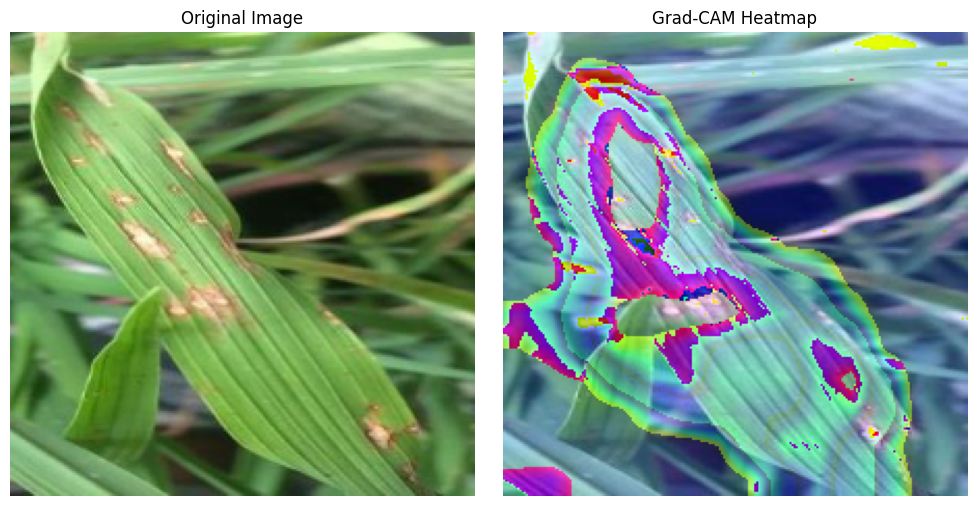

In [55]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read original image
img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))

# Prepare heatmap
heatmap_resized = cv2.resize(heatmap, (224,224))
heatmap_resized = np.uint8(255 * heatmap_resized)

# Apply color map
heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

# Overlay heatmap on original image
superimposed_img = heatmap_color * 0.4 + img


# Plot both images
plt.figure(figsize=(10,5))

# Original Image
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

# Grad-CAM Result
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(superimposed_img.astype("uint8"), cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.tight_layout()
plt.show()

Original image
2️⃣ Grad-CAM heatmap
3️⃣ Overlay (model attention on leaf)
This is the format commonly used in Explainable AI (XAI) sections of CNN papers.
✅ 3-Panel Grad-CAM Visualization Code

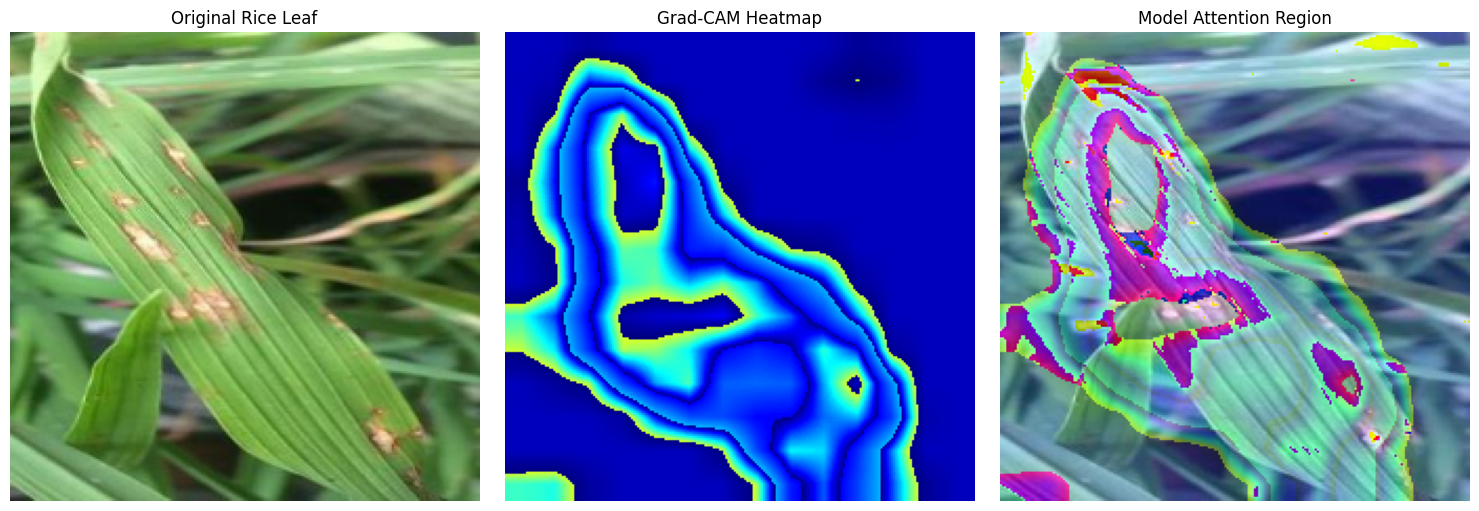

In [56]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read original image
img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))

# Resize heatmap
heatmap_resized = cv2.resize(heatmap, (224,224))
heatmap_resized = np.uint8(255 * heatmap_resized)

# Apply color map
heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

# Overlay heatmap on original image
superimposed_img = heatmap_color * 0.4 + img


# Plot results
plt.figure(figsize=(15,5))

# 1️⃣ Original Image
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Rice Leaf")
plt.axis("off")

# 2️⃣ Heatmap
plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM Heatmap")
plt.axis("off")

# 3️⃣ Overlay
plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(superimposed_img.astype("uint8"), cv2.COLOR_BGR2RGB))
plt.title("Model Attention Region")
plt.axis("off")

plt.tight_layout()
plt.show()

In [57]:
import tensorflow as tf
import numpy as np
import cv2

def gradcam_plus_plus(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_output)

    first = grads
    second = grads**2
    third = grads**3

    global_sum = tf.reduce_sum(conv_output, axis=(0,1,2))

    alpha_num = second
    alpha_denom = second*2 + third*global_sum
    alpha_denom = tf.where(alpha_denom != 0, alpha_denom, tf.ones_like(alpha_denom))

    alphas = alpha_num / alpha_denom

    weights = tf.reduce_sum(alphas * tf.nn.relu(first), axis=(0,1,2))

    cam = tf.reduce_sum(weights * conv_output[0], axis=-1)

    heatmap = tf.maximum(cam, 0)
    heatmap /= tf.reduce_max(heatmap)

    return heatmap.numpy()

In [58]:
heatmap_pp = gradcam_plus_plus(img_array, model, "block5_conv3")

1/1 [==============================] - 0s 28ms/step


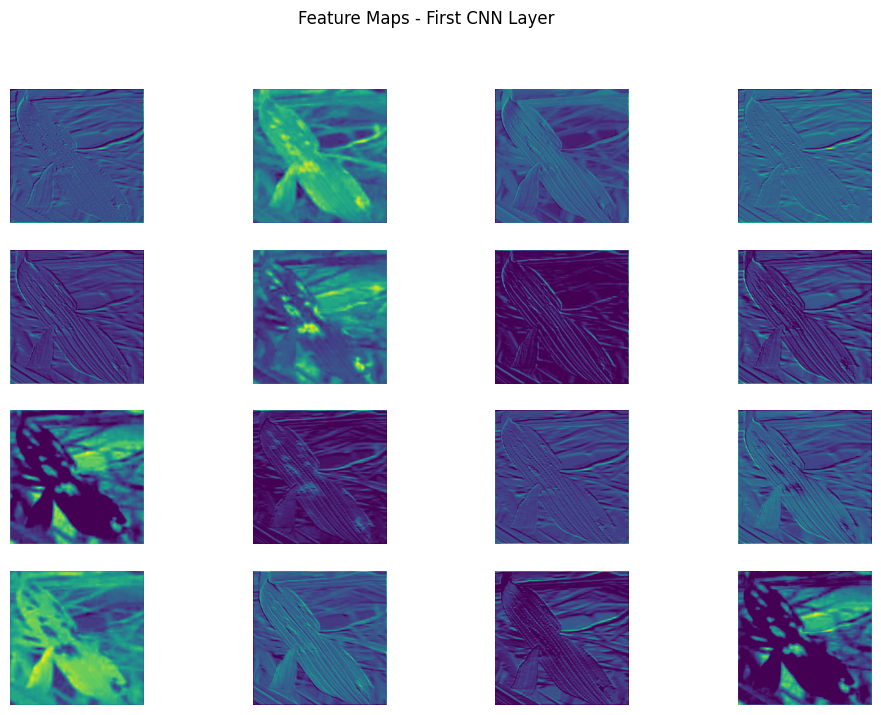

In [59]:
import matplotlib.pyplot as plt

layer_name = "block1_conv1"

feature_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=model.get_layer(layer_name).output
)

feature_maps = feature_model.predict(img_array)

plt.figure(figsize=(12,8))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(feature_maps[0,:,:,i], cmap="viridis")
    plt.axis("off")

plt.suptitle("Feature Maps - First CNN Layer")
plt.show()

Image shape: (224, 224, 3)
Mask shape: (224, 224)


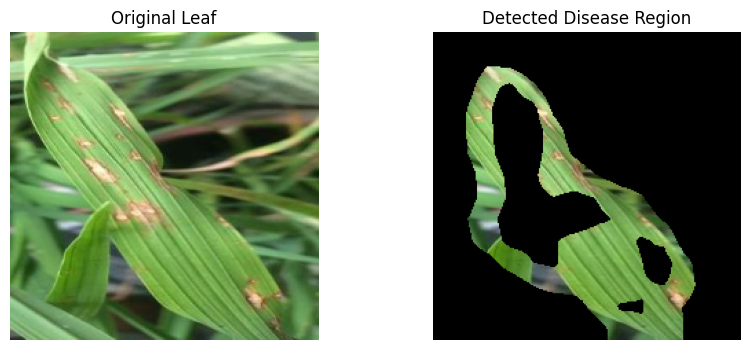

In [62]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read original image
img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))

# Resize heatmap
heatmap_resized = cv2.resize(heatmap, (224,224))

# Convert heatmap to 0-255
heatmap_resized = np.uint8(255 * heatmap_resized)

# Ensure single channel mask
if len(heatmap_resized.shape) == 3:
    heatmap_resized = cv2.cvtColor(heatmap_resized, cv2.COLOR_BGR2GRAY)

# Threshold mask
_, mask = cv2.threshold(heatmap_resized, 150, 255, cv2.THRESH_BINARY)

# Ensure mask type
mask = mask.astype(np.uint8)

# Final safety resize (guarantee same size)
mask = cv2.resize(mask, (img.shape[1], img.shape[0]))

print("Image shape:", img.shape)
print("Mask shape:", mask.shape)

# Extract disease region
disease_region = cv2.bitwise_and(img, img, mask=mask)

# Plot results
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Leaf")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(disease_region, cv2.COLOR_BGR2RGB))
plt.title("Detected Disease Region")
plt.axis("off")

plt.show()